# IEEE-CIS Fraud Detection - Exploratory Data Analysis

## Objective
Perform comprehensive exploratory data analysis on our dataset to:
1. Understand data structure and quality
2. Identify fraud patterns and signals
3. Discover feature relationships

# 1. Setup and Imports

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm
import warnings
import os

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# 2. Load and merge data

In [2]:
# Load data and merge
train_trans = pd.read_csv('../../data/raw/train_transaction.csv')
train_id = pd.read_csv('../../data/raw/train_identity.csv')

train = train_trans.merge(train_id, on='TransactionID', how='left')
print(f"Transactions with identity: {(~train['DeviceType'].isna()).sum()}")
print(f"Transactions without identity: {train['DeviceType'].isna().sum()}")
identity_rate = (1 - train['DeviceType'].isna().mean()) * 100
print(f"Percentage of transaction with identity: {identity_rate:.2f}%")
print(train.shape)

Transactions with identity: 140810
Transactions without identity: 449730
Percentage of transaction with identity: 23.84%
(590540, 434)


# 3. Initial Data Overview

In [3]:
print(train.shape)
print(f"{train.memory_usage(deep=True).sum() / 1024**2}MBs")
print(train.dtypes.value_counts())
print(train.isnull().sum())
display(train.head(3))
display(train.tail(3))

(590540, 434)
2567.094612121582MBs
float64    399
object      31
int64        4
Name: count, dtype: int64
TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590539,3577539,0,15811131,279.95,W,15066,170.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Statistical Summary (numeric features)
# Get numeric columns except 
numeric_features = train.select_dtypes(include=['int64', 'float64']).columns.to_list()
numeric_features.remove('TransactionID')
print(len(numeric_features))
summary = train[numeric_features].describe()
display(summary)

402


,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,118.502180,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,371.872026,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,0.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,3.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,8.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,24.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,10286.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [4]:
# Categorical features
categorical_features = train.select_dtypes(include=['object']).columns.to_list()
print(len(categorical_features))

for col in categorical_features[:15]:
    unique_count = train[col].nunique()
    missing_pct = (train[col].isna().sum() / len(train)) * 100

    print(f"{col:20s}: {unique_count:5d} unique values, {missing_pct:5.1f}% missing")

    if unique_count <= 20 and unique_count > 0:
        top_values = train[col].value_counts().head()
        print(f"Top values: {list(top_values.index)}")

31
ProductCD           :     5 unique values,   0.0% missing
Top values: ['W', 'C', 'R', 'H', 'S']
card4               :     4 unique values,   0.3% missing
Top values: ['visa', 'mastercard', 'american express', 'discover']
card6               :     4 unique values,   0.3% missing
Top values: ['debit', 'credit', 'debit or credit', 'charge card']
P_emaildomain       :    59 unique values,  16.0% missing
R_emaildomain       :    60 unique values,  76.8% missing
M1                  :     2 unique values,  45.9% missing
Top values: ['T', 'F']
M2                  :     2 unique values,  45.9% missing
Top values: ['T', 'F']
M3                  :     2 unique values,  45.9% missing
Top values: ['T', 'F']
M4                  :     3 unique values,  47.7% missing
Top values: ['M0', 'M2', 'M1']
M5                  :     2 unique values,  59.3% missing
Top values: ['F', 'T']
M6                  :     2 unique values,  28.7% missing
Top values: ['F', 'T']
M7                  :     2 unique values,

# 4. Target Variable (isFraud) Analysis
Analyse the distribution of fraud transactions vs legitimate transactions. Is there class imbalance?

In [9]:
# Analyse Fraud Distribution
fraud_count = train['isFraud'].sum()
total_count = len(train)
legitimate = total_count - fraud_count
fraud_rate = (fraud_count / total_count) * 100

print(f"Total transactions: {total_count}")
print(f"Transactions flagged as fraud: {fraud_count}")
print(f"Legitimate transactions: {legitimate}")
print(f"Percentage of transactions that are fraudulent: {fraud_rate:.2f}%")
print(f"Imbalance ratio: {(legitimate / fraud_count):.2f}")

Total transactions: 590540
Transactions flagged as fraud: 20663
Legitimate transactions: 569877
Percentage of transactions that are fraudulent: 3.50%
Imbalance ratio: 27.58


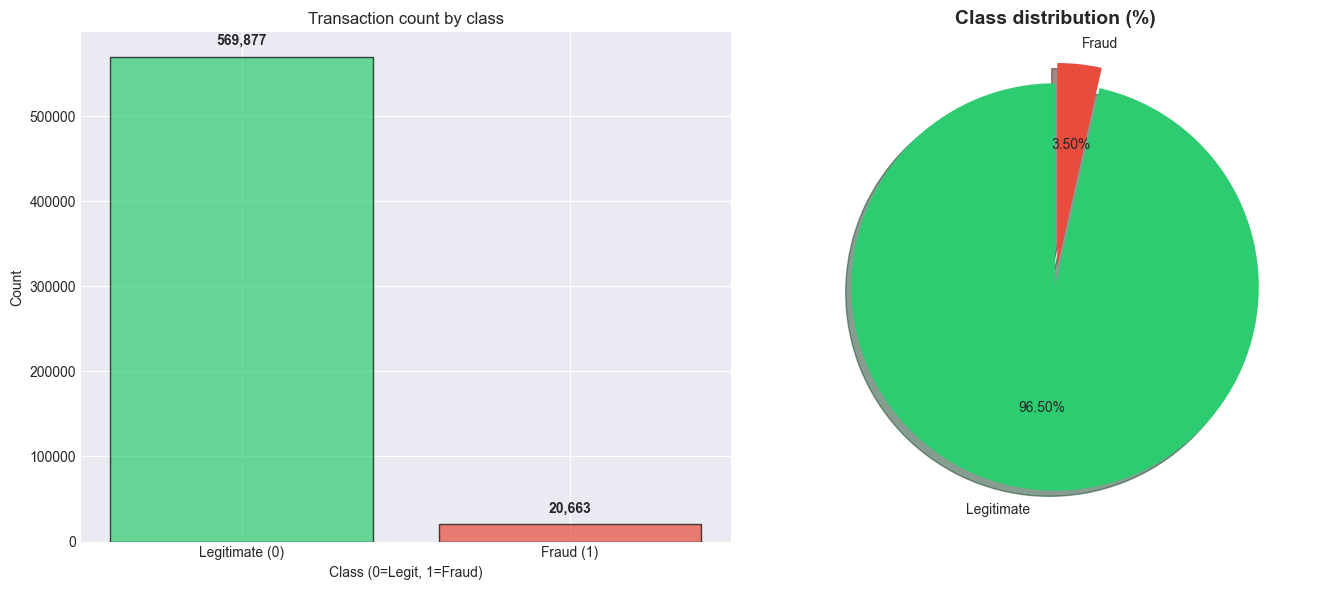

In [26]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_counts = train['isFraud'].value_counts()

# Subplot 1: Bar chart showing number of fraud and not fraud trnsactions
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, 
            color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_title('Transaction count by class')
axes[0].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Count')

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Pie Chart showing percentage distribution
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)
axes[1].pie(class_counts,
            labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%',
            colors=colors,
            explode=explode,
            shadow=True,
            startangle=90,
            )
axes[1].set_title('Class distribution (%)', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.savefig('../images/class_distribution.png')
plt.show()